## Naive Bayes Classifier

In this part we predict the label of each weld deposit directly, instead of predicting the four targets and applying the thresholds. The models of the `1D` notebooks are trained on the label itself (1 = non-conforming), on the weld deposits where it is known, and compared with the label of the regression models of the `1B` notebooks. The first one is the Gaussian naive Bayes classifier: it models each input within each class by a Gaussian, and assumes that the inputs are independent within a class.

### Main observations

- **Data:** 175 labelled deposits, 83 of them non-conforming (47%), 161 of them C-Mn. The direct classifiers learn from these 175 deposits only, the regression models of `1B` from 558 to 723 rows per target.
- **Naive Bayes on the inputs:** F1 of 0.42 and recall of 0.29, below the 0.64 of the rule that declares every deposit non-conforming. It misses 59 of the 83 non-conforming deposits, and 99% of its probabilities are below 0.01 or above 0.99.
- **Why:** The non-conforming class holds the typical MMA deposits and a few extreme ones (submerged arc, high sulphur and phosphorus), so its Gaussians are wide on the welding parameters and the impurities, while those of the conforming class are narrow. A typical deposit is closer to the narrow Gaussians, and the naive product counts this evidence once per correlated input (current, voltage, heat input, process, S, P). Smoothing the variances does not help (F1 of 0.43 at best).
- **PCA first:** Giving the naive Bayes the principal components of the standardised inputs, which are uncorrelated, instead of the inputs themselves raises the F1 to 0.70 and the recall to 0.69 (23 components). It is above the 0.64 of the reference rule, but below the label of every tree model of `1B` (F1 from 0.76 to 0.84).
- **Nested cross-validation:** F1 of 0.66. The number of components is chosen on the same folds as the evaluation, which makes the F1 of 0.70 a little optimistic.

### Operations in order

1. Load the train set with `load_train` and build the table of the labelled deposits with `deposit_data` and `get_deposit_xy`: one row per deposit, with its inputs, its fold and its label.
2. Count the deposits per family, label and fold, and look at the heat treatments of the deposits.
3. Compare the mean and the standard deviation of the standardised inputs in each class, which are the parameters of the Gaussians of the naive Bayes, and plot four of them.
4. Cross-validate the naive Bayes on the standardised inputs, and look at its probabilities, its confusion matrix and the contribution of each input to its decision.
5. Measure the correlations between the inputs within each class.
6. Tune `var_smoothing`, then the number of principal components given to the naive Bayes, by a grid search on the folds of `helpers/utils.py`, with the F1 on the non-conforming deposits as score.
7. Evaluate the best model with `evaluate_label`, and check its F1 by nested cross-validation.
8. Save it to `results.csv` and compare it with the label of the regression models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, f1_score, recall_score
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    PWHT_DEPOSIT_COLS, load_train, deposit_data, get_deposit_xy, build_pipeline,
    oof_predict_label, nested_oof_predict_label, evaluate_label, save_results,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
train = load_train()
deposits = deposit_data(train)
X, y, cv = get_deposit_xy(train)

print(X.shape)
display(pd.crosstab(deposits["family"], deposits["true_nc"], margins=True))
pd.crosstab(deposits["true_nc"], deposits["fold"], margins=True)

(175, 32)


true_nc,0,1,All
family,,,
C-Mn,82,79,161
CrMo2,7,1,8
CrMo91,3,3,6
All,92,83,175


fold,0,1,2,3,4,All
true_nc,,,,,,
0,18,15,20,21,18,92
1,17,17,17,15,17,83
All,35,32,37,36,35,175


`deposit_data` builds one row per labelled deposit, with the rule of `deposit_labels` used in `0_baseline`: a deposit is labelled when each of the 4 criteria is decided on at least one of its rows, and it is non-conforming (`true_nc = 1`) as soon as one criterion fails on one row. `get_deposit_xy` returns its inputs `X`, its label `y` and a splitter on the folds of `load_train`, so that each deposit is in the same fold as in `evaluate`.

- **Deposits:** 175, of which 83 are non-conforming (47%). The two classes are balanced, so the F1 and the recall can be read without correcting for a rare class. 161 deposits are C-Mn, only 8 are CrMo2 and 6 CrMo91, as in `0_baseline`.
- **Folds:** 32 to 37 deposits per fold, 15 to 17 of them non-conforming, so one deposit weighs about 3% of the F1 of a fold.
- **Less data than the regressions:** The label needs the four criteria, which are rarely all decided on the same deposit, so only 175 of the 496 deposits of the train set are labelled. The regression models of `1B` learn each target on every row where it is measured (558 to 723 rows).

In [4]:
display(deposits.groupby(PWHT_DEPOSIT_COLS)["true_nc"].agg(["size", "sum"]))

print("Constant inputs:", [c for c in X.columns if X[c].nunique() == 1])

size  sum
pwht_temp_C_low pwht_time_h_low pwht_temp_C_high pwht_time_h_high           
0.0             0.00            0.0              0.00                27   23
                                250.0            14.00               32    2
                                500.0            2.00                 3    1
                                580.0            2.00                55   32
                                620.0            1.00                 2    2
250.0           14.00           250.0            14.00               26   11
550.0           1.83            550.0            1.83                 1    1
580.0           2.00            580.0            2.00                15    7
690.0           2.33            690.0            2.33                 1    0
                10.00           690.0            10.00                7    1
750.0           8.00            750.0            8.00                 6    3

Constant inputs: ['AC_DC', 'electrode_polarity', 'weld_type_GMAA', 'weld_type_GTAA', 'weld_type_SAA']


The table gives the number of deposits (`size`) and of non-conforming deposits (`sum`) for each pair of heat treatments.

- **Heat treatment:** The composition and the welding parameters are the same on every row of a deposit (it is how `input_group` is built), but the post-weld heat treatment can change: 92 deposits were tested in several states, for example as welded and after a stress relief at 580 °C. The label holds for all the states of the deposit, so `deposit_data` describes it by its heat treatment with the lowest temperature (`_low`) and its heat treatment with the highest one (`_high`), which are equal for the 83 deposits tested in a single state.
- **Label per heat treatment:** Only 2 of the 32 deposits tested as welded with and without the 250 °C hydrogen removal treatment are non-conforming (the `Evans-AlTi`, `Evans-Ti/CMn` and `EvHtIp1979` MMA welds), against 23 of the 27 deposits tested as welded only. The latter hold the 11 tandem submerged arc deposits of `Pat-1981` and the 10 submerged arc deposits of `Kluket-CuMnB`, which are all non-conforming. The heat treatments therefore also identify papers and processes, and a model can use them for that.
- **Constant inputs:** `AC_DC`, `electrode_polarity` and the GMAA, GTAA and SAA processes take the same value on the 175 deposits: every labelled deposit was welded in DC with a positive electrode, and none with these three processes. They are left in `X`, a standardised constant input is 0 everywhere and changes no model.

In [5]:
Z = pd.DataFrame(StandardScaler().fit_transform(X), index=X.index, columns=X.columns)

per_class = pd.concat({"mean": Z.groupby(y).mean().T, "std": Z.groupby(y).std().T}, axis=1)
per_class.columns = ["mean_conforming", "mean_non_conforming", "std_conforming", "std_non_conforming"]
per_class.loc[(per_class["mean_non_conforming"] - per_class["mean_conforming"]).abs().sort_values(ascending=False).index[:10]].round(2)

,mean_conforming,mean_non_conforming,std_conforming,std_non_conforming
pwht_time_h_high,0.39,-0.44,0.99,0.82
heat_input_kJ_mm,-0.36,0.40,0.26,1.32
current_A,-0.32,0.35,0.44,1.30
voltage_V,-0.29,0.33,0.25,1.36
weld_type_TSA,-0.26,0.29,0.00,1.41
weld_type_MMA,0.25,-0.28,0.71,1.19
S,-0.19,0.21,0.15,1.42
O_ppm,0.18,-0.20,1.02,0.95
weld_type_SA,-0.15,0.17,0.73,1.22
P,-0.14,0.15,0.15,1.44


The naive Bayes fits one Gaussian per input and per class, with the mean and the variance of the input in the class. This table gives them on the standardised inputs, for the 10 inputs whose mean differs most between the two classes.

- **Welding parameters:** The non-conforming deposits have a higher heat input, current and voltage on average (+0.33 to +0.40 standard deviation of the inputs), and above all a much larger spread (1.30 to 1.36, against 0.25 to 0.44 for the conforming deposits). The 11 TSA deposits are all non-conforming, so `weld_type_TSA` has a standard deviation of 0 in the conforming class.
- **S, P:** The same pattern, a standard deviation of 0.15 in the conforming class against 1.42 and 1.44 in the non-conforming class. The 23 deposits with 0.013% S or more (the `Pat-1981` and `Kluket-CuMnB` deposits, `SurianEtAl-C` and `Mart-G`) are all non-conforming.
- **pwht_time_h_high:** The only input of the list with a lower mean in the non-conforming class, as most conforming deposits were tested after the 14 h hydrogen removal treatment (table above).

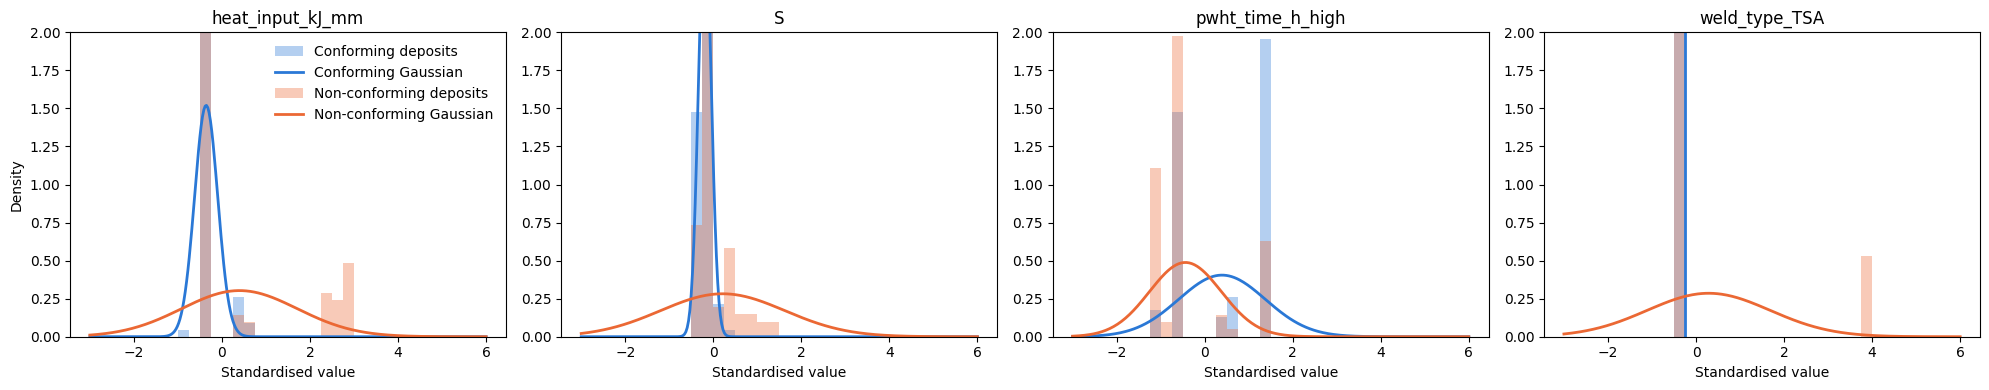

In [6]:
nb = GaussianNB().fit(Z, y)
x = np.linspace(-3, 6, 300)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, ["heat_input_kJ_mm", "S", "pwht_time_h_high", "weld_type_TSA"]):
    j = X.columns.get_loc(col)
    for label, color, name in [(0, "#2a78d6", "Conforming"), (1, "#eb6834", "Non-conforming")]:
        ax.hist(Z.loc[y == label, col], bins=np.linspace(-3, 6, 37), density=True, color=color, alpha=0.35, label=f"{name} deposits")
        mean, var = nb.theta_[label, j], nb.var_[label, j]
        if var < 1e-6:
            ax.axvline(mean, color=color, linewidth=2)
        else:
            ax.plot(x, np.exp(-(x - mean) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var), color=color, linewidth=2, label=f"{name} Gaussian")
    ax.set_ylim(0, 2)
    ax.set_title(col)
    ax.set_xlabel("Standardised value")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

The histograms of 4 of these inputs in each class, with the Gaussians of the naive Bayes fitted on the 175 deposits. The y-axis is cut at 2 so that the Gaussians stay readable.

- **heat_input_kJ_mm, S:** The conforming deposits form a narrow peak. The non-conforming deposits form the same peak plus a group of large values (the submerged arc deposits for the heat input). Their Gaussian is wide to cover this group, so it is low on the peak, where most non-conforming deposits are.
- **weld_type_TSA:** The conforming class has no TSA deposit, so its Gaussian has a variance of almost 0 (only `var_smoothing`, 1e-9 times the largest variance) and is drawn as a vertical line. A TSA deposit is then infinitely more likely to be non-conforming, and any other deposit much more likely to be conforming, on this input alone.
- **Gaussian assumption:** None of these inputs is Gaussian: `weld_type_TSA` is binary, the heat input and S are skewed, and `pwht_time_h_high` only takes the few durations used by the papers.

In [7]:
scores = cross_validate(build_pipeline(GaussianNB()), X, y, cv=cv, scoring=["f1", "recall", "precision"], return_train_score=True)

pd.DataFrame({split: {metric: scores[f"{split}_{metric}"].mean() for metric in ["f1", "recall", "precision"]} for split in ["train", "test"]}).round(3)

,train,test
f1,0.467,0.417
recall,0.319,0.287
precision,0.874,0.803


`cross_validate` gives the F1, the recall and the precision on the non-conforming deposits, on the train folds and on the validation fold (`test`), averaged over the 5 folds.

- **Underfitting:** The F1 is low on the validation fold (0.42) and also on the train folds (0.47): the model cannot even describe its training deposits, so it is not a problem of overfitting. It is below the 0.64 of the rule that declares every deposit non-conforming.
- **Recall, precision:** It catches only 29% of the non-conforming deposits, but 80% of its alarms are right: it only declares non-conforming the deposits that are far from the peaks of the conforming class.

In [8]:
oof = oof_predict_label(GaussianNB(), train)

print("Probabilities below 0.01 or above 0.99:", ((oof["score"] < 0.01) | (oof["score"] > 0.99)).mean().round(3))
pd.DataFrame(confusion_matrix(y, oof["pred_nc"]), index=["conforming", "non-conforming"], columns=["predicted conforming", "predicted non-conforming"])

Probabilities below 0.01 or above 0.99: 0.994


,predicted conforming,predicted non-conforming
conforming,85,7
non-conforming,59,24


`oof_predict_label` gives the out-of-fold prediction of each deposit (`pred_nc`) and the out-of-fold probability of the non-conforming class (`score`).

- **Probabilities:** 99.4% of them are below 0.01 or above 0.99. The naive Bayes multiplies the likelihoods of the 32 inputs as if they were independent, so a small gap on each input becomes a huge ratio. These probabilities cannot be used to move the decision threshold.
- **Confusion matrix:** 59 of the 83 non-conforming deposits are predicted conforming, for 7 false alarms out of the 92 conforming deposits.

In [9]:
contributions = []
for train_idx, val_idx in cv.split():
    pipe = build_pipeline(GaussianNB()).fit(X.iloc[train_idx], y.iloc[train_idx])
    theta, var = pipe["model"].theta_[:, None, :], pipe["model"].var_[:, None, :]
    Z_val = pipe["scaler"].transform(X.iloc[val_idx])
    log_density = -0.5 * np.log(2 * np.pi * var) - (Z_val - theta) ** 2 / (2 * var)
    contributions.append(pd.DataFrame(log_density[1] - log_density[0], index=X.index[val_idx], columns=X.columns))
contributions = pd.concat(contributions).loc[X.index]

missed = (y == 1) & (oof["pred_nc"] == 0)
pd.DataFrame({
    "median_all": contributions.median(),
    "median_missed": contributions[missed].median(),
    "max_abs": contributions.abs().max(),
}).sort_values("median_missed").head(10).round(2)

,median_all,median_missed,max_abs
weld_type_TSA,-10.78,-10.78,9.155769e+09
S,-1.96,-2.03,3.013460e+03
P,-1.66,-2.00,2.469370e+03
heat_input_kJ_mm,-1.67,-1.80,8.897000e+01
voltage_V,-1.71,-1.73,2.324400e+02
current_A,-1.27,-1.27,3.195000e+01
weld_type_MMA,-0.75,-0.75,6.410000e+00
weld_type_SA,-0.61,-0.61,1.319000e+01
Si,-0.27,-0.31,5.080000e+00
V,-0.21,-0.21,1.653000e+01


The naive Bayes predicts "non-conforming" when $\log \frac{P(\text{nc})}{P(\text{c})} + \sum_j \log \frac{p(x_j \mid \text{nc})}{p(x_j \mid \text{c})} > 0$, a sum of one term per input. The table gives the term of each input, computed on the validation fold with the Gaussians of the train folds: its median over the 175 deposits, its median over the 59 missed non-conforming deposits, and its largest absolute value. A negative term pushes toward the conforming class. The first term, the log-ratio of the class shares, is only -0.1.

- **weld_type_TSA:** -10.8 for every deposit that is not TSA: the conforming Gaussian of this input is so narrow that it is about 50,000 times higher than the non-conforming one at 0. For a TSA deposit, the term reaches 10^10 the other way.
- **Correlated inputs:** S and P (-2.0 each on the missed deposits), then the heat input, the voltage and the current (-1.3 to -1.8) all say the same thing, that the deposit is in the narrow peak of the conforming class. The naive Bayes adds them up, about -20 with TSA, which a typical non-conforming MMA deposit cannot compensate.

In [10]:
within = {}
for label, name in [(0, "conforming"), (1, "non_conforming")]:
    corr = X[y == label].loc[:, X[y == label].std() > 0].corr().abs()
    within[name] = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().dropna()
within = pd.DataFrame(within)

print("Pairs above 0.5:", (within > 0.5).sum().to_dict(), "out of", len(within))
within.sort_values("non_conforming", ascending=False).head(10).round(2)

Pairs above 0.5: {'conforming': 51, 'non_conforming': 57} out of 351


,,conforming,non_conforming
current_A,heat_input_kJ_mm,0.84,0.98
S,P,0.36,0.98
P,weld_type_FCA,0.35,0.98
current_A,weld_type_MMA,0.91,0.98
Cr,Nb_ppm,0.81,0.97
voltage_V,weld_type_TSA,NaN,0.97
heat_input_kJ_mm,weld_type_MMA,0.90,0.96
S,weld_type_FCA,0.52,0.96
AC_DC_unknown,pwht_time_h_low,0.86,0.92
Cr,V,0.89,0.89


The absolute correlation between each pair of inputs within each class, without the constant inputs (`weld_type_TSA` is constant in the conforming class, hence the empty cell).

- **Independence:** 51 pairs above 0.5 in the conforming class and 57 in the non-conforming class, out of 351. The naive assumption is far from true.
- **Welding parameters:** Current, heat input and MMA process are correlated at 0.84 to 0.91 in the conforming class and 0.96 to 0.98 in the non-conforming class: the MMA deposits use a low current, the submerged arc deposits a high one.
- **S, P and FCA:** 0.96 to 0.98 in the non-conforming class, against 0.35 to 0.52 in the conforming class. A single deposit makes it: `Mart-G`, the only non-conforming FCA deposit, has 10 times more S and P than the other FCA deposits (see the units notebook).

In [11]:
smoothing = GridSearchCV(
    build_pipeline(GaussianNB()),
    {"model__var_smoothing": np.logspace(-9, 0, 10)},
    cv=cv,
    scoring="f1",
    return_train_score=True,
).fit(X, y)

pd.DataFrame({
    "var_smoothing": smoothing.cv_results_["param_model__var_smoothing"],
    "train_F1": smoothing.cv_results_["mean_train_score"],
    "validation_F1": smoothing.cv_results_["mean_test_score"],
}).set_index("var_smoothing").round(3)

,train_F1,validation_F1
var_smoothing,,
1.000000e-09,0.467,0.417
1.000000e-08,0.467,0.417
1.000000e-07,0.466,0.417
1.000000e-06,0.465,0.417
1.000000e-05,0.467,0.417
1.000000e-04,0.466,0.417
1.000000e-03,0.466,0.417
1.000000e-02,0.466,0.430
1.000000e-01,0.453,0.398


`var_smoothing` adds a share of the largest variance of the inputs (about 1 once standardised) to the variance of every Gaussian, which widens the narrow ones. The grid search uses the folds of `get_deposit_xy` and the F1 on the non-conforming deposits as score, as every grid search of the `1D` notebooks.

- **Validation F1:** Between 0.40 and 0.43 for every value. Widening the Gaussians removes the huge terms of `weld_type_TSA`, but the correlated inputs are still counted several times, so the naive Bayes stays below the reference rule.

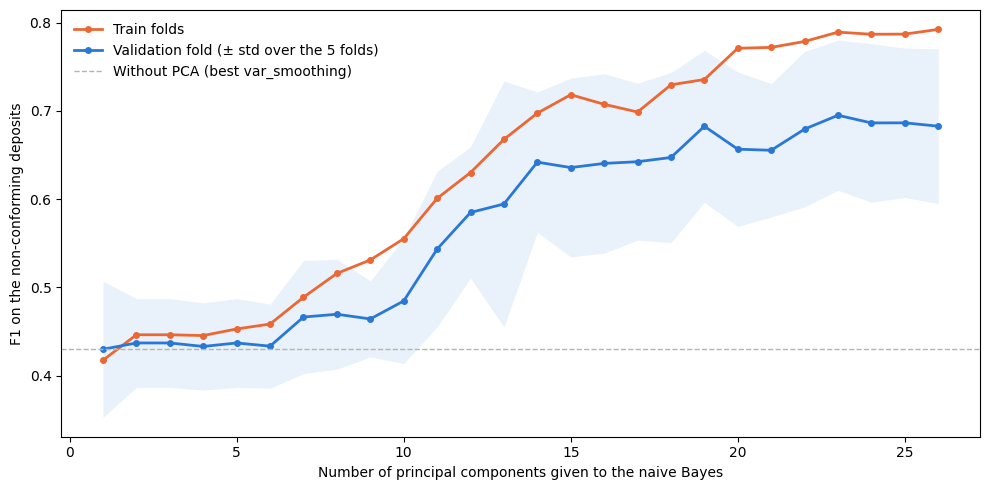

{'pca__n_components': 23} validation F1: 0.695 ±  0.085


In [12]:
search = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("pca", PCA()), ("model", GaussianNB())]),
    {"pca__n_components": range(1, 27)},
    cv=cv,
    scoring="f1",
    return_train_score=True,
).fit(X, y)

n_components = search.cv_results_["param_pca__n_components"].astype(int)
val_f1, val_std = search.cv_results_["mean_test_score"], search.cv_results_["std_test_score"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(n_components, val_f1 - val_std, val_f1 + val_std, color="#2a78d6", alpha=0.1, linewidth=0)
ax.plot(n_components, search.cv_results_["mean_train_score"], color="#eb6834", linewidth=2, marker="o", markersize=4, label="Train folds")
ax.plot(n_components, val_f1, color="#2a78d6", linewidth=2, marker="o", markersize=4, label="Validation fold (± std over the 5 folds)")
ax.axhline(smoothing.best_score_, color="#b5b4ae", linewidth=1, linestyle="--", label="Without PCA (best var_smoothing)")
ax.set_xlabel("Number of principal components given to the naive Bayes")
ax.set_ylabel("F1 on the non-conforming deposits")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(search.best_params_, "validation F1:", round(search.best_score_, 3), "± ", round(val_std[search.best_index_], 3))

The naive Bayes is now fitted on the first principal components of the standardised inputs. The `PCA` is inside the pipeline, so it is fitted on the train folds only. The principal components are uncorrelated on the train folds, and the correlated inputs (the welding parameters, S and P) are gathered in the same components instead of being counted one by one. The 32 inputs have 27 non-constant columns and a rank of 26, hence at most 26 components.

- **Few components:** With 1 to 6 components, the F1 stays at the level of the naive Bayes without PCA (0.43 to 0.44). The first components mostly follow the alloy family and the welding process (see the EDA notebook), which only separate a few non-conforming deposits.
- **More components:** The F1 rises from 7 components on and reaches 0.70 with 23 components, with 0.79 on the train folds. The information on the label is spread over many small components, as the information on the inputs in the EDA notebook (12 components for 80% of the variance).
- **Uncertainty:** The standard deviation over the folds is 0.09 at 23 components, and the curve is flat between 19 and 26 components (0.66 to 0.70), so the exact number of components is not precise.

In [13]:
best = search.best_estimator_

naive_bayes = evaluate_label("Naive Bayes classifier", best, train)
display(naive_bayes.dropna(axis=1, how="all").round(2))

oof = oof_predict_label(best, train)
pd.DataFrame(confusion_matrix(y, oof["pred_nc"]), index=["conforming", "non-conforming"], columns=["predicted conforming", "predicted non-conforming"])

,model,target,family,n_clf,n_nc,F1_nc,recall_nc,accuracy,precision_good
0,Naive Bayes classifier,label,all,175,83,0.70,0.69,0.72,0.73
1,Naive Bayes classifier,label,C-Mn,161,79,0.71,0.70,0.73,0.72
2,Naive Bayes classifier,label,CrMo2,8,1,0.00,0.00,0.88,0.88
3,Naive Bayes classifier,label,CrMo91,6,3,0.50,0.67,0.33,0.00


,predicted conforming,predicted non-conforming
conforming,69,23
non-conforming,26,57


`evaluate_label` cross-validates the model on the same folds and returns the same rows as the label rows of `evaluate`: `n_clf` labelled deposits, `n_nc` of them non-conforming, and the F1 and the recall on the non-conforming deposits, for all the deposits and per family. The regression columns are empty and are not displayed.

- **All deposits:** F1 of 0.70 and recall of 0.69, above the 0.64 of the rule that declares every deposit non-conforming. The F1 of `evaluate_label` is computed on the out-of-fold predictions of the 175 deposits, the F1 of the grid search is the mean of the F1 of the 5 folds, hence a small gap (0.70 against 0.695).
- **Confusion matrix:** 57 of the 83 non-conforming deposits are caught, for 23 false alarms out of 92 conforming deposits (a precision of 0.71).
- **Per family:** The C-Mn deposits give the same values. The single non-conforming CrMo2 deposit is missed, 2 of the 3 non-conforming CrMo91 deposits are caught: on 8 and 6 deposits, these values are only indicative.

In [14]:
nested_pred, nested_params = nested_oof_predict_label(search, train)

print("Nested F1:", round(f1_score(y, nested_pred), 3), "| recall:", round(recall_score(y, nested_pred), 3))
nested_params

Nested F1: 0.662 | recall: 0.639


,pca__n_components
fold,
0,25
1,20
2,25
3,22
4,24


The number of components is chosen on the same 5 folds as those used to evaluate the model, so the F1 of the best number is a little optimistic: among 26 numbers, the best one is also the luckiest on these folds. `nested_oof_predict_label` redoes the grid search for each fold, on the 4 other folds only, and predicts the fold with the model it selects: the fold being evaluated plays no part in the choice.

- **Nested F1:** 0.66, and a recall of 0.64. The choice of the number of components on the same folds adds about 0.04 to the F1.
- **Chosen components:** 20 to 25 depending on the fold, all on the flat part of the curve.

In [15]:
results = save_results(naive_bayes)

models = ["Baseline (mean)", "Pruned CART", "Bagging", "Random forest", "Extra-Trees", "Naive Bayes classifier"]
label = results[(results["target"] == "label") & results["model"].isin(models)]
label.pivot(index="model", columns="family", values=["F1_nc", "recall_nc", "accuracy", "precision_good"]).reindex(index=models).reindex(columns=["all", "C-Mn", "CrMo2", "CrMo91"], level="family").round(2)

F1_nc                    recall_nc                     \
family                   all  C-Mn CrMo2 CrMo91       all  C-Mn CrMo2 CrMo91   
model                                                                          
Baseline (mean)         0.00  0.00   0.0    0.0      0.00  0.00   0.0   0.00   
Pruned CART             0.77  0.78   1.0    0.0      0.81  0.84   1.0   0.00   
Bagging                 0.81  0.83   0.0    0.5      0.72  0.75   0.0   0.33   
Random forest           0.76  0.77   0.0    0.5      0.64  0.66   0.0   0.33   
Extra-Trees             0.84  0.85   0.0    0.8      0.72  0.73   0.0   0.67   
Naive Bayes classifier  0.70  0.71   0.0    0.5      0.69  0.70   0.0   0.67   

                       accuracy                    precision_good              \
family                      all  C-Mn CrMo2 CrMo91            all  C-Mn CrMo2   
model                                                                           
Baseline (mean)            0.53  0.51  0.88   0.50           0.53  0.51  0.88   
Pruned CART                0.77  0.77  1.00   0.33           0.81  0.82  1.00   
Bagging                    0.84  0.84  0.88   0.67           0.79  0.79  0.88   
Random forest              0.81  0.81  0.88   0.67           0.75  0.74  0.88   
Extra-Trees                0.87  0.87  0.88   0.83           0.80  0.80  0.88   
Naive Bayes classifier     0.72  0.73  0.88   0.33           0.73  0.72  0.88   

                               
family                 CrMo91  
model                          
Baseline (mean)          0.50  
Pruned CART              0.40  
Bagging                  0.60  
Random forest            0.60  
Extra-Trees              0.75  
Naive Bayes classifier   0.00

`results.csv` now holds the naive Bayes classifier, next to the label of the regression models of `1B` (the four regressions and the thresholds). With the PCA, the naive Bayes is above the reference rule, but below every tree model on the F1 (0.70 against 0.76 to 0.84). Its recall (0.69) is close to that of the random forest (0.64), the bagging and the Extra-Trees (0.72), and below that of the pruned tree (0.81).